In [2]:
import os 
import json 
import networkx as nx 
import matplotlib.pyplot as plt 


from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader,
    Docx2txtLoader
)
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.documents import Document


In [4]:
from dotenv import find_dotenv,load_dotenv

load_dotenv(find_dotenv(),override=True)

if os.environ["GROQ_API_KEY"]:
    print("Api key found ")
else:
    print('Api key not found ')

Api key found 


# **Defined Function To load Data**

In [7]:
file_path='impactOfCovid19.pdf'

def load_document(path):

    # Check the file the type and start that loader only 
    
    if path.endswith(".pdf"):
       loader=PyPDFLoader(path)
    elif path.endswith(".txt"):
        loader=TextLoader(path)
    elif path.endswith(".docx"):
        loader=Docx2txtLoader(path)
    else:
        raise ValueError("Unsupported Format")
    
    # Load the documents now
    documents=loader.load()
    return documents



In [8]:
documents=load_document(file_path)
print(f"Loaded {len(documents)} document pages")

Loaded 26 document pages


In [9]:
documents[0].page_content

'NBER WORKING PAPER SERIES\nTHE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS:  \nEVIDENCE FROM A SURVEY\nEsteban M. Aucejo\nJacob F. French\nMaria Paola Ugalde Araya\nBasit Zafar\nWorking Paper 27392\nhttp://www.nber.org/papers/w27392\nNATIONAL BUREAU OF ECONOMIC RESEARCH\n1050 Massachusetts Avenue\nCambridge, MA 02138\nJune 2020\nNoah Deitrick and Adam Streff provided excellent research assistance. All errors that remain are \nours. The views expressed herein are those of the authors and do not necessarily reflect the views \nof the National Bureau of Economic Research.\nNBER working papers are circulated for discussion and comment purposes. They have not been \npeer-reviewed or been subject to the review by the NBER Board of Directors that accompanies \nofficial NBER publications.\n© 2020 by Esteban M. Aucejo, Jacob F. French, Maria Paola Ugalde Araya, and Basit Zafar. All \nrights reserved. Short sections of text, not to exceed two paragraphs, may be quoted without \ne

# **Chunk the Document**

In [10]:
splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunks=splitter.split_documents(documents)

print(f'Total Chunks:{len(chunks)}')

Total Chunks:159


In [11]:
chunks[0].page_content

'NBER WORKING PAPER SERIES\nTHE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS:  \nEVIDENCE FROM A SURVEY\nEsteban M. Aucejo\nJacob F. French\nMaria Paola Ugalde Araya\nBasit Zafar\nWorking Paper 27392\nhttp://www.nber.org/papers/w27392\nNATIONAL BUREAU OF ECONOMIC RESEARCH\n1050 Massachusetts Avenue\nCambridge, MA 02138\nJune 2020\nNoah Deitrick and Adam Streff provided excellent research assistance. All errors that remain are'

# **Embeddings**

In [13]:
embedding_model=HuggingFaceBgeEmbeddings(
    model_name="all-miniLM-L6-v2"
)
print("Embedding Model Loaded ")

Embedding Model Loaded 


In [15]:
vector_store=Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory='./chroma_db'
)

retriever=vector_store.as_retriever(search_kwargs={"k":3})

print('Chroma_DB Created Successfully')

Chroma_DB Created Successfully


# **Automatic Entity and Realtionship Extraction**

In [22]:
extraction_prompt = '''
You are an information extraction system.

Extract:

1. Entities
2. Relationships

Return ONLY valid JSON.

Format:

{{
  "entities": ["entity1", "entity2"],
  "relationships": [
    {{
      "source": "entity1",
      "target": "entity2",
      "relationship": "relation_name"
    }}
  ]
}}

TEXT:
{text}
'''

# **Extract Graph Data**

In [35]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import find_dotenv,load_dotenv

load_dotenv(find_dotenv(),override=True)

llm1=ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite",
                            temperature=0)


In [25]:
llm=ChatGroq(
    model="llama-3.3-70b-versatile",
             temperature=0)
print(f'{llm.model_name} Loaded Successfully')

llama-3.3-70b-versatile Loaded Successfully


In [40]:
def extract_graph_data(text):

    prompt = extraction_prompt.format(text=text[:4000])

    response = llm1.invoke(prompt)

    content = response.content.strip()

    # Remove markdown code blocks if present
    if content.startswith("```"):

        content = content.replace("```json", "")
        content = content.replace("```", "")
        content = content.strip()

    try:
        data = json.loads(content)
        return data

    except Exception as e:

        print("JSON Parsing Error")
        print(e)

        print(content[:1000])

        return {
            "entities": [],
            "relationships": []
        }

In [41]:
graph_results=[]

for chunk in chunks[:10]:
    result=extract_graph_data(chunk.page_content)
    graph_results.append(result)
print("Extraction Completed")

Extraction Completed


In [42]:
graph_results[0]

{'entities': ['NBER WORKING PAPER SERIES',
  'THE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS: EVIDENCE FROM A SURVEY',
  'Esteban M. Aucejo',
  'Jacob F. French',
  'Maria Paola Ugalde Araya',
  'Basit Zafar',
  'Working Paper 27392',
  'http://www.nber.org/papers/w27392',
  'NATIONAL BUREAU OF ECONOMIC RESEARCH',
  '1050 Massachusetts Avenue',
  'Cambridge, MA 02138',
  'June 2020',
  'Noah Deitrick',
  'Adam Streff'],
 'relationships': [{'source': 'Esteban M. Aucejo',
   'target': 'THE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS: EVIDENCE FROM A SURVEY',
   'relationship': 'author of'},
  {'source': 'Jacob F. French',
   'target': 'THE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS: EVIDENCE FROM A SURVEY',
   'relationship': 'author of'},
  {'source': 'Maria Paola Ugalde Araya',
   'target': 'THE IMPACT OF COVID-19 ON STUDENT EXPERIENCES AND EXPECTATIONS: EVIDENCE FROM A SURVEY',
   'relationship': 'author of'},
  {'source': 'Basit Zafar',


In [46]:

G = nx.Graph()

for item in graph_results:

    relationships = item.get("relationships", [])

    for rel in relationships:

        source = rel.get("source")
        target = rel.get("target")
        relation = rel.get("relationship")

        if source and target:

            G.add_node(source)
            G.add_node(target)

            G.add_edge(
                source,
                target,
                relationship=relation
            )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 67
Edges: 82


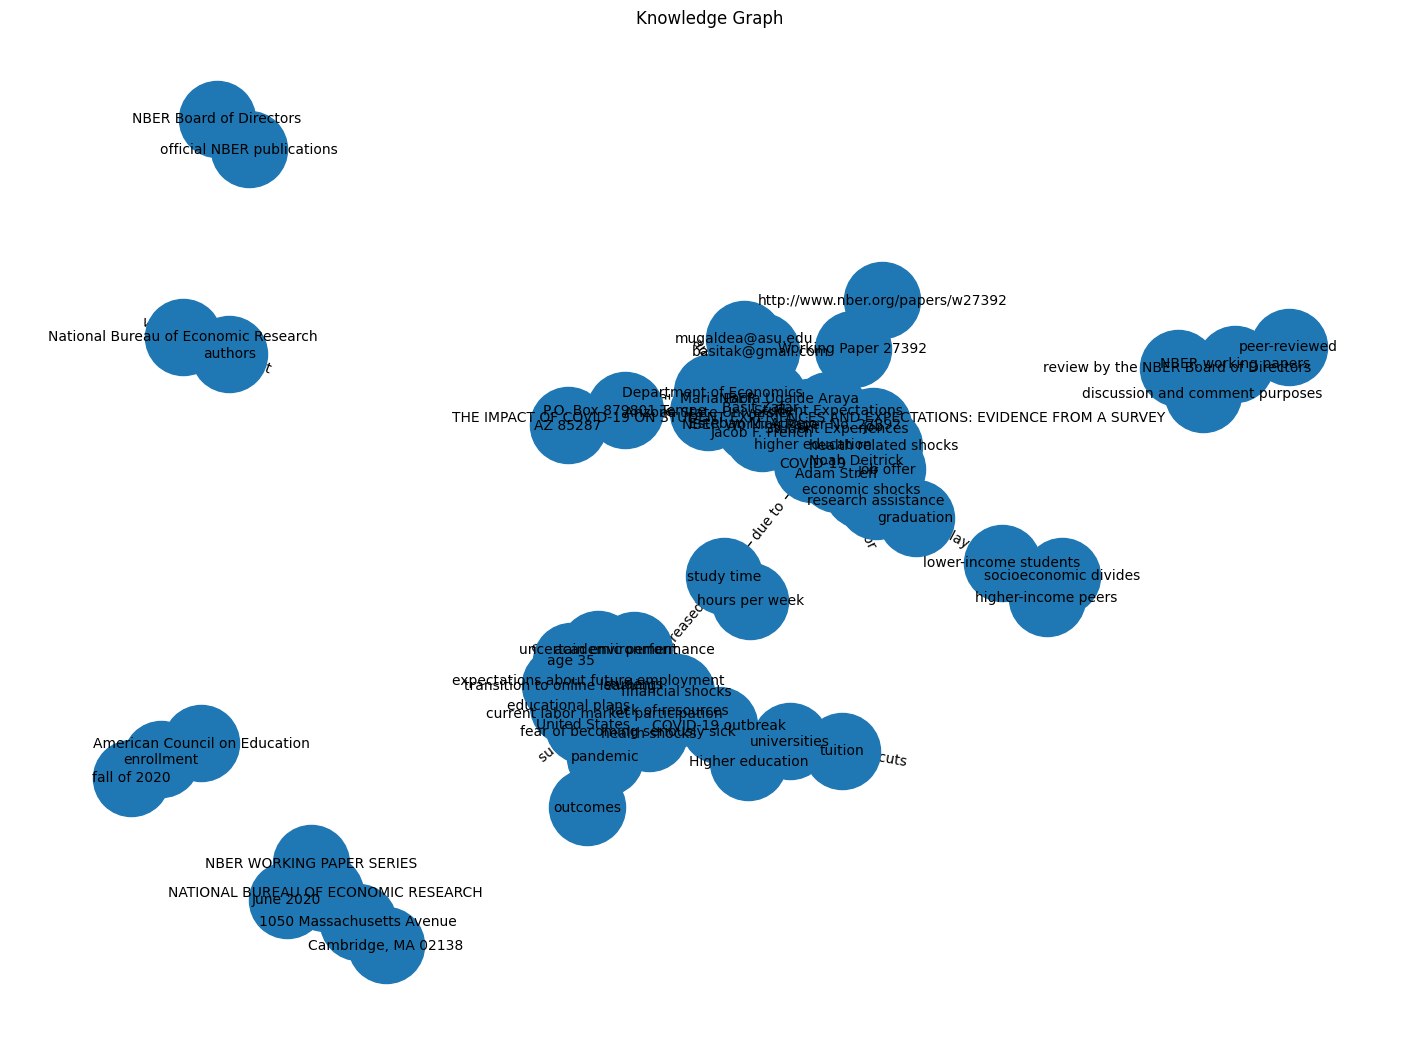

In [47]:

plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10
)

edge_labels = nx.get_edge_attributes(G, "relationship")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Knowledge Graph")
plt.show()


In [50]:
from pyvis.network import Network

net = Network(height="700px", width="100%", notebook=True)

for node in G.nodes():
    net.add_node(node, label=node)

for source, target, data in G.edges(data=True):

    net.add_edge(
        source,
        target,
        title=data.get("relationship", "")
    )

net.show("graph.html")

graph.html


In [53]:
def vector_rag(question):

    docs = retriever.invoke(question)

    context = "\n\n".join(
        [doc.page_content for doc in docs]
    )

    prompt = f'''
Answer the question using the context.

Context:
{context}

Question:
{question}
'''

    response = llm1.invoke(prompt)

    return response.content

In [54]:

question = "What is the main topic of the document?"

answer = vector_rag(question)

print(answer)


The main topic of the document is the **discussion surrounding students' demands for tuition cuts**, as indicated by the phrase "discussion surrounding students’ demands for tuition cuts" in the context.


# Test **Graph RAG**

In [56]:

def graph_rag(question):

    nodes = list(G.nodes())

    matched_nodes = []

    question_lower = question.lower()

    for node in nodes:

        if node.lower() in question_lower:
            matched_nodes.append(node)

    if not matched_nodes:
        return "No related graph nodes found"

    context = []

    for node in matched_nodes:

        neighbors = list(G.neighbors(node))

        for neighbor in neighbors:

            edge_data = G.get_edge_data(node, neighbor)

            relation = edge_data.get("relationship", "")

            context.append(
                f"{node} -- {relation} --> {neighbor}"
            )

    graph_context = "\n".join(context)

    prompt = f'''
Use the graph relationships to answer.

Graph Context:
{graph_context}

Question:
{question}
'''

    response = llm1.invoke(prompt)

    return response.content


In [60]:

question = "The Role of Economic and Health Shocks on students due to covid 19"

answer = graph_rag(question)

print(answer)


Based on the provided graph relationships, here's how economic and health shocks played a role for students due to COVID-19:

**Economic Shocks:**

*   **Financial Shocks:** Students were affected by financial shocks.
*   **Lack of Resources:** Students were affected by a lack of resources.
*   **Expectations about Future Employment:** Students' expectations about future employment were affected.
*   **Current Labor Market Participation:** Students' current labor market participation was affected.
*   **Expect to Earn Less at Age 35:** Students expect to earn less at age 35.

**Health Shocks:**

*   **Health Shocks:** Students were affected by health shocks.
*   **Fear of Becoming Seriously Sick:** Fear of becoming seriously sick is an example of a health shock that affected students.

**Overall Impact of COVID-19:**

The COVID-19 outbreak and the pandemic had a broad impact on students, leading to:

*   **Uncertain Environment:** Students faced an uncertain environment.
*   **Transiti

**User Chooses Retrivel Type**

In [62]:

def ask_question(question, mode="vector"):

    if mode == "vector":
        return vector_rag(question)

    elif mode == "graph":
        return graph_rag(question)

    else:
        return "Invalid mode"


In [61]:

question = input("Enter your question: ")

mode = input("Choose mode (vector/graph): ")

answer = ask_question(question, mode)

print("\nAnswer:\n")
print(answer)


NameError: name 'ask_question' is not defined